# $\mathrm{Ca}_{\mathrm{V}}1.2$: predicted and experimental distance analysis

This notebook compares Cα–Cα distance distributions from AlphaFold2 ensembles with
distances measured in experimental structures. Data are loaded from versioned GitHub
raw URLs so the analysis can run outside the original workstation.

## Interpretation guide

- A narrow violin indicates that the predicted ensemble consistently samples a similar geometry.
- An experimental marker inside the main violin density is compatible with the predicted ensemble.
- A marker near a tail indicates partial or rare sampling of the experimental conformation.
- A marker outside the predicted range identifies a systematic structural difference worth inspecting.

Distances alone do **not** constitute a structural superposition. They are invariant to rigid-body
alignment and therefore allow local geometry comparisons without superposing coordinates. A true
superposition analysis (aligned Cα RMSD, aligned residue coverage, and domain-specific RMSD) requires
the predicted and experimental coordinate files, which are not included in this repository. The
distance comparisons below should consequently be interpreted as local structural agreement, not
as a global RMSD analysis.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import sys
repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
from shared.dataset_selection import distance_csv_options, load_selected_distance_csv


In [2]:
from shared.presentation_export import install_notebook_figure_export
WRITING_FIGURE_DIR = repo_root.parent / 'vgci_mutants_writing' / 'figures' / 'cav12'
install_notebook_figure_export(WRITING_FIGURE_DIR, 'Cav12_distanceDistribution_vsExperimental')


PosixPath('/Users/ahernandezgonzalez/Repositories/vgci_mutants_writing/figures/cav12/Cav12_distanceDistribution_vsExperimental')

In [3]:
# Cav1.2 WT and mutant ensembles: explicit paths and one shared selection.
DATASET_SELECTION = 'all_ok_3'  # Corrected 3 Å convergence subset stored in cav12/dataDistances; switch to 'all' to inspect unfiltered rows.
data = repo_root / 'cav12' / 'dataDistances'
DATASET_PATHS = {
    'WT vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_vanillaAF2_distances_all.csv', 'Cav12', 'WT', 'vanilla'),
    'WT masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_wt_maskedAF2_distances_all.csv', 'Cav12', 'WT', 'masked'),
    'G402S vanilla': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_vanillaAF2_distances_all.csv', 'Cav12', 'G402S', 'vanilla'),
    'G402S masked': distance_csv_options(repo_root, data / '26-02-10_Cav12_g402s_maskedAF2_distances_all.csv', 'Cav12', 'G402S', 'masked'),
    'G406R vanilla': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_vanillaAF2_distances_all.csv', 'Cav12', 'G406R', 'vanilla'),
    'G406R masked': distance_csv_options(repo_root, data / '26-07-25_Cav1.2_g406r_maskedAF2_distances_all.csv', 'Cav12', 'G406R', 'masked'),
}
DATASET_PATHS
df_wt_vanilla = load_selected_distance_csv('WT vanilla', DATASET_PATHS['WT vanilla'], DATASET_SELECTION)
df_wt_masked = load_selected_distance_csv('WT masked', DATASET_PATHS['WT masked'], DATASET_SELECTION)
df_g402s_vanilla = load_selected_distance_csv('G402S vanilla', DATASET_PATHS['G402S vanilla'], DATASET_SELECTION)
df_g402s_masked = load_selected_distance_csv('G402S masked', DATASET_PATHS['G402S masked'], DATASET_SELECTION)
df_g406r_vanilla = load_selected_distance_csv('G406R vanilla', DATASET_PATHS['G406R vanilla'], DATASET_SELECTION)
df_g406r_masked = load_selected_distance_csv('G406R masked', DATASET_PATHS['G406R masked'], DATASET_SELECTION)
print(f'Loaded WT, G402S, and G406R datasets using requested selection: {DATASET_SELECTION}')


WT vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all_ok_rmsd_3A.csv
WT masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all_ok_rmsd_3A.csv


G402S vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_vanillaAF2_distances_all_ok_rmsd_3A.csv
G402S masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-02-10_Cav12_g402s_maskedAF2_distances_all_ok_rmsd_3A.csv


G406R vanilla: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_vanillaAF2_distances_all_ok_rmsd_3A.csv
G406R masked: requested=all_ok_3; actual=all_ok_3; path=/Users/ahernandezgonzalez/Repositories/vgci_mutants/cav12/dataDistances/26-07-25_Cav1.2_g406r_maskedAF2_distances_all_ok_rmsd_3A.csv


Loaded WT, G402S, and G406R datasets using requested selection: all_ok_3


## Experimental-distance comparisons

Experimental markers provide local structural references for the selectivity filter, intracellular
gate, and voltage sensors. WT and mutant ensembles are compared with identical residue definitions,
using the 3 Å convergence-filtered datasets throughout.


In [4]:
# Experimental marker palette: distinct, high-contrast accents on white marker faces.
from shared.plotting import CAV12_PALETTE
CAV_EXPERIMENTAL_COLORS = [
    "#E57373", "#F48FB1", "#F06292", "#FF8A65",
    "#FFB74D", "#FFCC99", "#FFD89A", "#FFE082", "#FFF176", "#FFF6B3",
]


In [5]:
from shared.plotting import plot_distances_by_alias_violin


/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


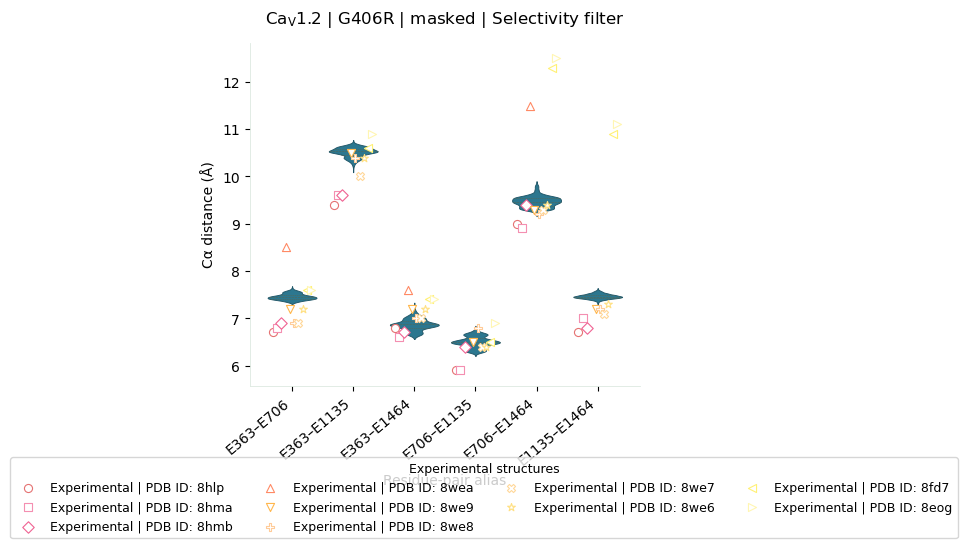

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


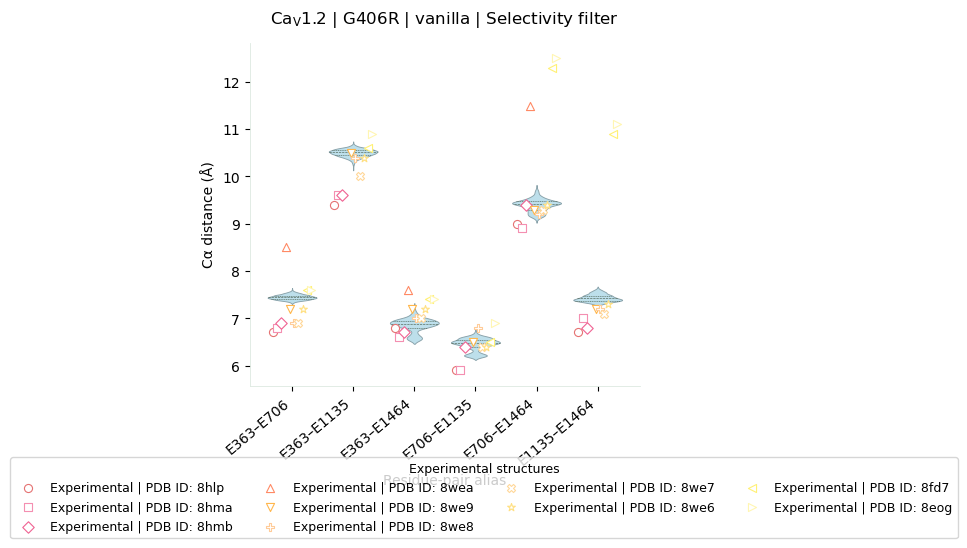

<Axes: title={'center': '$\\mathrm{Ca}_{\\mathrm{V}}1.2$ | G406R | vanilla | Selectivity filter'}, xlabel='Residue-pair alias', ylabel='Cα distance (Å)'>

In [6]:
# Selectivity-filter distance set.
alias_dict = {
    'E363-E706': 'CA_GLU363_CA-GLU706_CA',
    'E363-E1135': 'CA_GLU363_CA-GLU1135_CA',
    'E363-E1464': 'CA_GLU363_CA-GLU1464_CA',
    'E706-E1135': 'CA_GLU706_CA-GLU1135_CA',
    'E706-E1464': 'CA_GLU706_CA-GLU1464_CA',
    'E1135-E1464': 'CA_GLU1135_CA-GLU1464_CA',
}

# Colors distinguish the six selectivity-filter pairs.
custom_colors = ['#53acc9', '#89d7eb', '#91c7f9', '#53acc9', '#4dabae', '#9370DB']

# Experimental distances to overlay (multiple datasets with lists for each alias)
exp_distances_list = [
    { #8hlp
        'E363-E706': [6.7],
        'E363-E1135': [9.4],
        'E363-E1464': [6.8],
        'E706-E1135': [5.9],
        'E706-E1464': [9.0],
        'E1135-E1464': [6.7]
    },
    { #8hma
        'E363-E706': [6.8],
        'E363-E1135': [9.6],
        'E363-E1464': [6.6],
        'E706-E1135': [5.9],
        'E706-E1464': [8.9],
        'E1135-E1464': [7.0]
    },
    { #8hmb
        'E363-E706': [6.9],
        'E363-E1135': [9.6],
        'E363-E1464': [6.7],
        'E706-E1135': [6.4],
        'E706-E1464': [9.4],
        'E1135-E1464': [6.8]
    },
    { #8wea
        'E363-E706': [8.5],
        #'E363-E1135': [],
        'E363-E1464': [7.6],
        #'E706-E1135': [],
        'E706-E1464': [11.5],
        #'E1135-E1464': []
    },
    { #8we9
        'E363-E706': [7.2],
        'E363-E1135': [10.5],
        'E363-E1464': [7.2],
        'E706-E1135': [6.5],
        'E706-E1464': [9.3],
        'E1135-E1464': [7.2]
    },
    { #8we8
        'E363-E706': [6.9],
        'E363-E1135': [10.4],
        'E363-E1464': [7.0],
        'E706-E1135': [6.8],
        'E706-E1464': [9.2],
        'E1135-E1464': [7.2]
    },
    { #8we7
        'E363-E706': [6.9],
        'E363-E1135': [10.0],
        'E363-E1464': [7.0],
        'E706-E1135': [6.4],
        'E706-E1464': [9.3],
        'E1135-E1464': [7.1]
    },
    { #8we6
        'E363-E706': [7.2],
        'E363-E1135': [10.4],
        'E363-E1464': [7.2], 
        'E706-E1135': [6.4],
        'E706-E1464': [9.4],
        'E1135-E1464': [7.3]
    },
    { #8fd7
        'E363-E706': [7.6],
        'E363-E1135': [10.6], #E1115
        'E363-E1464': [7.4],#1416
        'E706-E1135': [6.5], #E1115
        'E706-E1464': [12.3],
        'E1135-E1464': [10.9]
    },
    { #8eog
        'E363-E706': [7.6],
        'E363-E1135': [10.9],
        'E363-E1464': [7.4],#1416
        'E706-E1135': [6.9],
        'E706-E1464': [12.5],
        'E1135-E1464': [11.1]
    }
]

# Labels for the datasets
dataset_labels = ['Experimental | PDB ID: 8hlp', 'Experimental | PDB ID: 8hma', 'Experimental | PDB ID: 8hmb','Experimental | PDB ID: 8wea','Experimental | PDB ID: 8we9','Experimental | PDB ID: 8we8','Experimental | PDB ID: 8we7','Experimental | PDB ID: 8we6','Experimental | PDB ID: 8fd7','Experimental | PDB ID: 8eog']

# Custom colors for each PDB dataset
pdb_colors = ['#AC5336', '#D77614','#F99E09','#AC5336','#AB524D','#6BD0A3']

# Compare the masked and vanilla G406R ensembles with the same references.
#plot_distances_by_alias_violin(df, alias_dict, xp_distances_list=exp_distances_list, title_custom_add='Selectivity Filter Subsampling 32-64', colors=[CAV12_PALETTE['G406R_HM']] * len(alias_dict), fig_width=14, fig_height=8, dataset_labels=dataset_labels, pdb_colors=pdb_colors)
plot_distances_by_alias_violin(df_g406r_masked , alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | masked | Selectivity filter', colors=[CAV12_PALETTE['G406R_HM']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)
plot_distances_by_alias_violin(df_g406r_vanilla, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | vanilla | Selectivity filter', colors=[CAV12_PALETTE['G406R_VAN']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


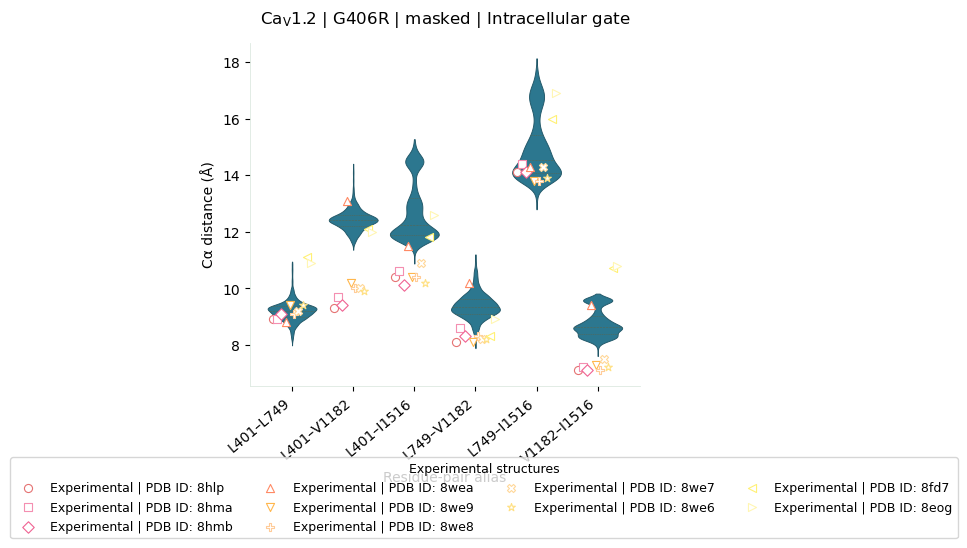

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


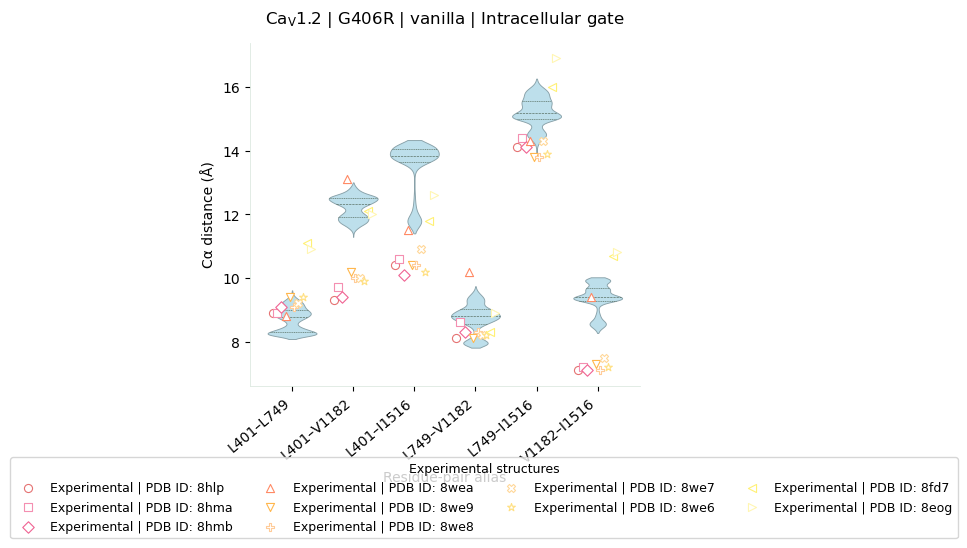

<Axes: title={'center': '$\\mathrm{Ca}_{\\mathrm{V}}1.2$ | G406R | vanilla | Intracellular gate'}, xlabel='Residue-pair alias', ylabel='Cα distance (Å)'>

In [7]:
# Intracellular-gate distance set.
alias_dict = {
    'L401-L749':'CA_LEU401_CA-LEU749_CA',
    'L401-V1182':'CA_LEU401_CA-VAL1182_CA',
    'L401-I1516':'CA_LEU401_CA-ILE1516_CA',
    'L749-V1182':'CA_LEU749_CA-VAL1182_CA',
    'L749-I1516':'CA_LEU749_CA-ILE1516_CA',
    'V1182-I1516':'CA_VAL1182_CA-ILE1516_CA'
}

# A related color family keeps the six gate pairs visually grouped.
custom_colors = ['#eb5c9e', '#ea96a3', '#e689e6', '#e891c3', '#d057a8', '#e1818f']

# Experimental distances to overlay (example values, with lists for each alias)
exp_distances_list = [
    { #8hlp
    'L401-L749':[8.9],
    'L401-V1182':[9.3],
    'L401-I1516':[10.4],
    'L749-V1182':[8.1],
    'L749-I1516':[14.1],
    'V1182-I1516':[7.1]
}, { #8hma
    'L401-L749':[8.9],
    'L401-V1182':[9.7],
    'L401-I1516':[10.6],
    'L749-V1182':[8.6],
    'L749-I1516':[14.4],
    'V1182-I1516':[7.2]
}, { #8hmb
    'L401-L749':[9.1],
    'L401-V1182':[9.4],
    'L401-I1516':[10.1],
    'L749-V1182':[8.3],
    'L749-I1516':[14.1],
    'V1182-I1516':[7.1]
}, { #8wea
    'L401-L749':[8.8],
    'L401-V1182':[13.1],
    'L401-I1516':[11.5],
    'L749-V1182':[10.2],
    'L749-I1516':[14.3],
    'V1182-I1516':[9.4]
}, { #8we9
    'L401-L749':[9.4],
    'L401-V1182':[10.2],
    'L401-I1516':[10.4],
    'L749-V1182':[8.1],
    'L749-I1516':[13.8],
    'V1182-I1516':[7.3]
}, { #8we8
    'L401-L749':[9.1],
    'L401-V1182':[10.0],
    'L401-I1516':[10.4],
    'L749-V1182':[8.3],
    'L749-I1516':[13.8],
    'V1182-I1516':[7.1]
}, { #8we7
    'L401-L749':[9.2],
    'L401-V1182':[10.0],
    'L401-I1516':[10.9],
    'L749-V1182':[8.2],
    'L749-I1516':[14.3],
    'V1182-I1516':[7.5]
}, { #8we6
    'L401-L749':[9.4],
    'L401-V1182':[9.9],
    'L401-I1516':[10.2],
    'L749-V1182':[8.2],
    'L749-I1516':[13.9],
    'V1182-I1516':[7.2]
}, { #8fd7
    'L401-L749':[11.1],
    'L401-V1182':[12.1], #1162
    'L401-I1516':[11.8], #1468
    'L749-V1182':[8.3], #1162
    'L749-I1516':[16],
    'V1182-I1516':[10.7]
}, { #
    'L401-L749':[10.9],
    'L401-V1182':[12.0],
    'L401-I1516':[12.6],
    'L749-V1182':[8.9],
    'L749-I1516':[16.9],
    'V1182-I1516':[10.8]
}
]
# Labels for the datasets
dataset_labels = ['Experimental | PDB ID: 8hlp', 'Experimental | PDB ID: 8hma', 'Experimental | PDB ID: 8hmb','Experimental | PDB ID: 8wea','Experimental | PDB ID: 8we9','Experimental | PDB ID: 8we8','Experimental | PDB ID: 8we7','Experimental | PDB ID: 8we6','Experimental | PDB ID: 8fd7','Experimental | PDB ID: 8eog']

# Custom colors for each PDB dataset
pdb_colors = ['#ff5733', '#33ff57', '#3375ff', '#ff33c4', '#ffd633', '#33fff5']

# Compare the masked and vanilla G406R gate distributions.
plot_distances_by_alias_violin(df_g406r_masked, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | masked | Intracellular gate', colors=[CAV12_PALETTE['G406R_HM']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)

plot_distances_by_alias_violin(df_g406r_vanilla, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | G406R | vanilla | Intracellular gate', colors=[CAV12_PALETTE['G406R_VAN']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


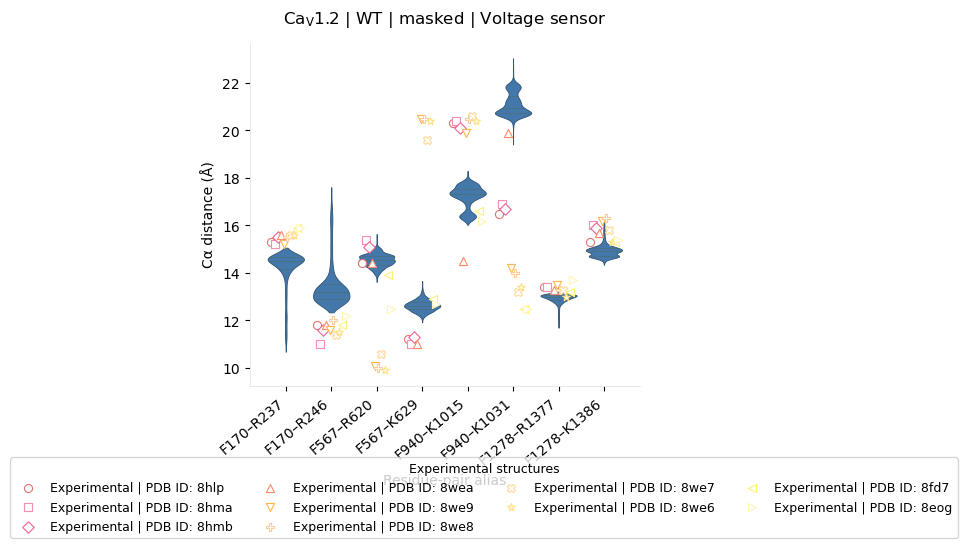

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:367: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


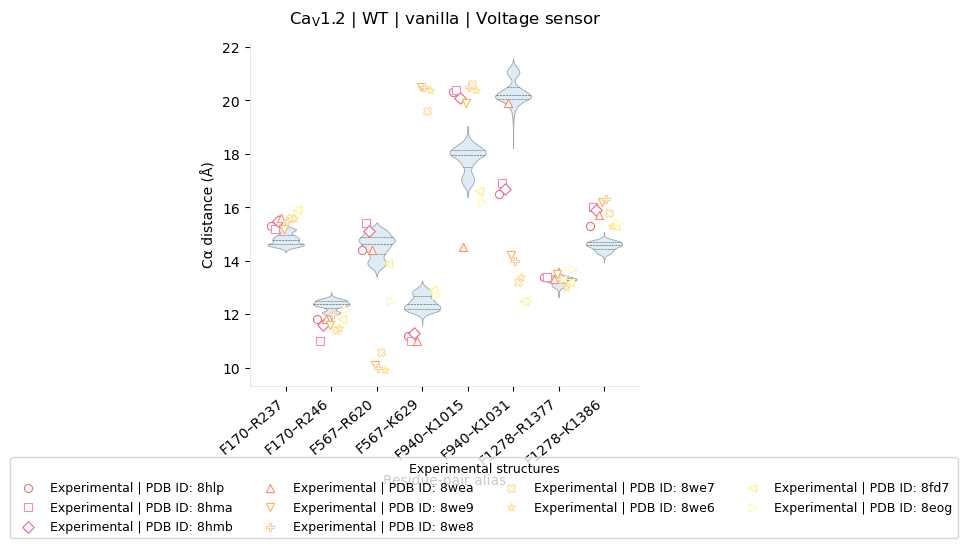

<Axes: title={'center': '$\\mathrm{Ca}_{\\mathrm{V}}1.2$ | WT | vanilla | Voltage sensor'}, xlabel='Residue-pair alias', ylabel='Cα distance (Å)'>

In [8]:
# Gating charges vs the aromatic middle in S2
alias_dict = {
    'F170-R237': 'CA_ARG237_CA-PHE170_CA',
    'F170-R246': 'CA_ARG246_CA-PHE170_CA',
    'F567-R620': 'CA_ARG620_CA-PHE567_CA',
    'F567-K629': 'CA_LYS629_CA-PHE567_CA',####
    'F940-K1015': 'CA_LYS1015_CA-PHE940_CA',
    'F940-K1031': 'CA_ARG1031_CA-PHE940_CA',
    'F1278-R1377': 'CA_ARG1377_CA-PHE1278_CA',
    'F1278-K1386': 'CA_LYS1386_CA-PHE1278_CA',
    #'F1278-R1390': 'CA_ARG1279_CA-PHE1167_CA',
}

# Colors distinguish the voltage-sensor measurements.
custom_colors = ['#9fa046','#92a348', '#7aaa48','#6aae52', '#4fb38c','#4aac99','#43b5b1','#3ebbbd']

# Experimental distances to overlay (multiple datasets with lists for each alias)
exp_distances_list = [
    { #8hlp
    'F170-R237': [15.3],
    'F170-R246': [11.8],
    'F567-R620': [14.4],
    'F567-K629': [11.2],
    'F940-K1015': [20.3],
    'F940-K1031': [16.5],
    'F1278-R1377': [13.4],
    'F1278-K1386':[15.3],
    #'F1278-R1390': [20.2]
   },
    { #8hma
     'F170-R237': [15.2],
    'F170-R246': [11.0],
    'F567-R620': [15.4],
    'F567-K629': [11.0],
    'F940-K1015': [20.4],
    'F940-K1031': [16.9],
    'F1278-R1377': [13.4],
    'F1278-K1386':[16.0],
    #'F1278-R1390': [20.8]
    },
    { #8hmb
    'F170-R237': [15.5],
    'F170-R246': [11.6],
    'F567-R620': [15.1],
    'F567-K629': [11.3],
    'F940-K1015': [20.1],
    'F940-K1031': [16.7],
    'F1278-K1386':[15.9],
   # 'F1278-R1390': [20.5]    
    },
    { #8wea
    'F170-R237': [15.6],
    'F170-R246': [11.8],
    'F567-R620': [14.4],
    'F567-K629': [11.0],
    'F940-K1015': [14.5], #960
    'F940-K1031': [19.9], #960,1027
    'F1278-R1377': [13.3],
    'F1278-K1386':[15.7],
    #'F1278-R1390': [21.2]   
    },
    { #8we9
    'F170-R237': [15.2],
    'F170-R246': [11.6],
    'F567-R620': [10.1],
    'F567-K629': [20.5],
    'F940-K1015': [19.9],
    'F940-K1031': [14.2],
    'F1278-R1377': [13.5],
    'F1278-K1386':[16.2],
    #'F1278-R1390': [20.9]    
    },
    { #8we8
    'F170-R237': [15.5],
    'F170-R246': [12.0],
    'F567-R620': [10.0],
    'F567-K629': [20.5],
    'F940-K1015': [20.5],
    'F940-K1031': [14.0],
    'F1278-R1377': [13.3],
    'F1278-K1386':[16.3],
    #'F1278-R1390': [21.5]    
    },
    { #8we7
    'F170-R237': [15.6],
    'F170-R246': [11.4],
    'F567-R620': [10.6],
    'F567-K629': [19.6],
    'F940-K1015': [20.6],
    'F940-K1031': [13.2],
    'F1278-R1377': [13.3],
    'F1278-K1386': [15.8], #1278,1386
    #'F1278-R1390': [20.2]    
    },
    { #8we6
    'F170-R237': [15.6],
    'F170-R246': [11.5],
    'F567-R620': [9.9],
    'F567-K629': [20.4],
    'F940-K1015': [20.4],
    'F940-K1031': [13.4],
    'F1278-R1377': [13.0],
    'F1278-K1386': [15.3], #1258
    #'F1278-R1390': [21.4]    
    },
    { #8fd7
    'F170-R237': [15.9],
    'F170-R246': [11.8],
    'F567-R620': [13.9],
    'F567-K629': [12.9], 
    'F940-K1015': [16.6], #F944,995
    'F940-K1031': [12.5],
    'F1278-R1377': [13.2], #1258,1329
    'F1278-K1386': [15.3],
    #'F1278-R1390': [20.2] #1258,1342
    },
    { #8eog
    'F170-R237': [15.9],
    'F170-R246': [12.2],
    'F567-R620': [12.5],
    'F567-K629': [12.7],
    'F940-K1015': [16.2],
    'F940-K1031': [12.5],
    'F1278-R1377': [13.7],
    'F1278-K1386': [15.4],
    #'F1278-R1390': [20.5]    
    }
]

# Labels for the datasets
dataset_labels = ['Experimental | PDB ID: 8hlp', 'Experimental | PDB ID: 8hma', 'Experimental | PDB ID: 8hmb','Experimental | PDB ID: 8wea','Experimental | PDB ID: 8we9','Experimental | PDB ID: 8we8','Experimental | PDB ID: 8we7','Experimental | PDB ID: 8we6','Experimental | PDB ID: 8fd7','Experimental | PDB ID: 8eog']

# Custom colors for each PDB dataset
pdb_colors = ['#AC5336', '#D77614','#F99E09','#AC5336','#AB524D','#6BD0A3','#50C878','#88D499']

# WT voltage-sensor distributions with experimental references.
plot_distances_by_alias_violin(df_wt_masked , alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | WT | masked | Voltage sensor', colors=[CAV12_PALETTE['WT_HM']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)

plot_distances_by_alias_violin(df_wt_vanilla, alias_dict, exp_distances_list=exp_distances_list, title_custom_add='Cav1.2 | WT | vanilla | Voltage sensor', colors=[CAV12_PALETTE['WT_VAN']] * len(alias_dict), fig_width=6, fig_height=6, dataset_labels=dataset_labels, pdb_colors=CAV_EXPERIMENTAL_COLORS)


In [9]:
from shared.plotting import plot_split_violin


In [10]:
# Compare the two candidate interaction distances in the WT masked ensemble.
# The experimental-overlay panels below provide the corresponding ensemble comparison.


### Voltage-sensor comparison

Voltage-sensor distances are compared first in WT and then across the two mutant ensembles. The same
residue definitions are retained across protocols so changes in distribution width can be attributed
to masking or mutation rather than to a change in the measurement itself.


## WT–mutant and masked–vanilla split comparisons

The final comparison section uses split violins so both ensemble halves remain directly visible.


## Mutation-site correspondence comparisons


In [11]:
## Cav1.2 mutation-site correspondence distances
CAV12_MUTATION_CORRESPONDENCE = {
    "selectivity_filter": {
        "E363-E706":"CA_GLU363_CA-GLU706_CA", "E363-E1135":"CA_GLU363_CA-GLU1135_CA",
        "E363-E1464":"CA_GLU363_CA-GLU1464_CA", "E706-E1135":"CA_GLU706_CA-GLU1135_CA",
        "E706-E1464":"CA_GLU706_CA-GLU1464_CA", "E1135-E1464":"CA_GLU1135_CA-GLU1464_CA",
    },
    "intracellular_gate": {
        "L401-L749":"CA_LEU401_CA-LEU749_CA", "L401-V1182":"CA_LEU401_CA-VAL1182_CA",
        "L401-I1516":"CA_LEU401_CA-ILE1516_CA", "L749-V1182":"CA_LEU749_CA-VAL1182_CA",
        "L749-I1516":"CA_LEU749_CA-ILE1516_CA", "V1182-I1516":"CA_VAL1182_CA-ILE1516_CA",
    },
    "voltage_sensor": {
        "F170-R237":"CA_ARG237_CA-PHE170_CA", "F170-R246":"CA_ARG246_CA-PHE170_CA",
        "F567-R620":"CA_ARG620_CA-PHE567_CA", "F567-K629":"CA_LYS629_CA-PHE567_CA",
        "F940-K1015":"CA_LYS1015_CA-PHE940_CA", "F940-K1031":"CA_ARG1031_CA-PHE940_CA",
        "F1278-R1377":"CA_ARG1377_CA-PHE1278_CA", "F1278-K1386":"CA_LYS1386_CA-PHE1278_CA",
    },
}

# These aliases feed the experimental split-violin matrix below. Transparent superpositions are intentionally omitted.


## Additional split-violin views


/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


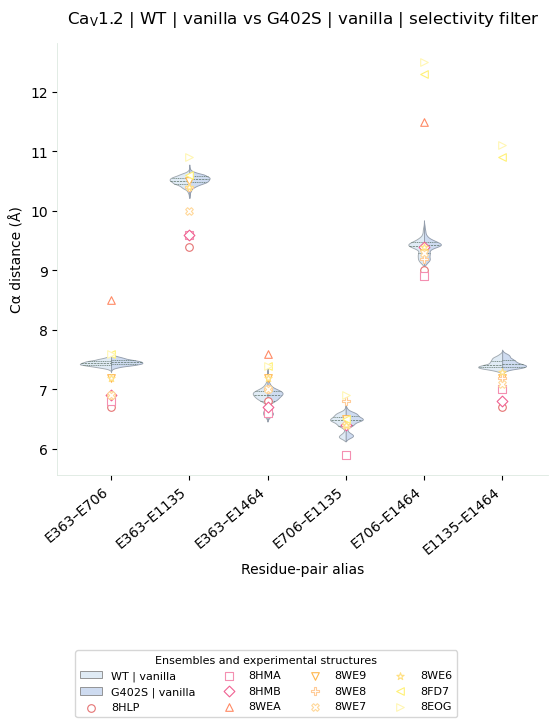

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


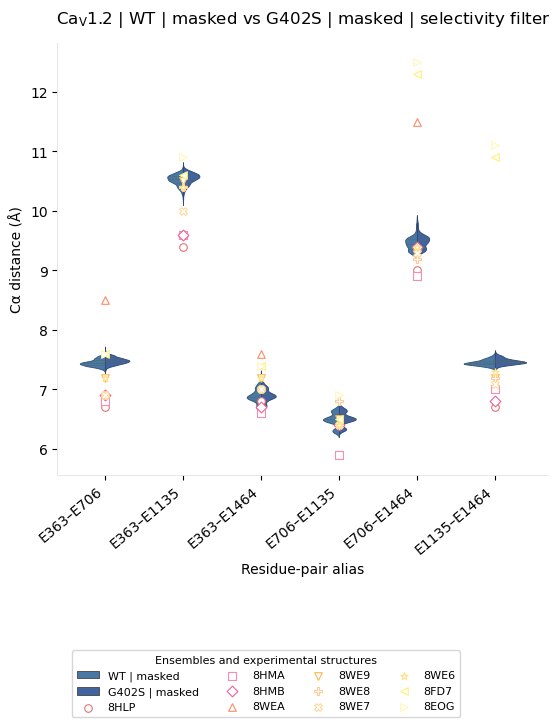

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


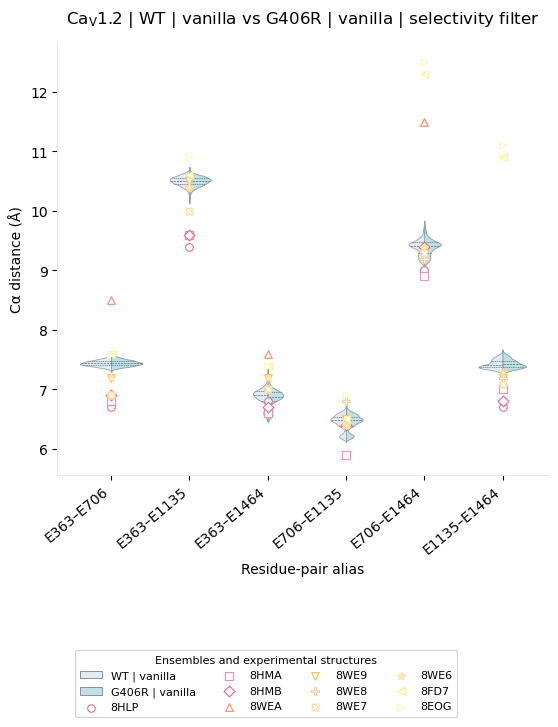

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


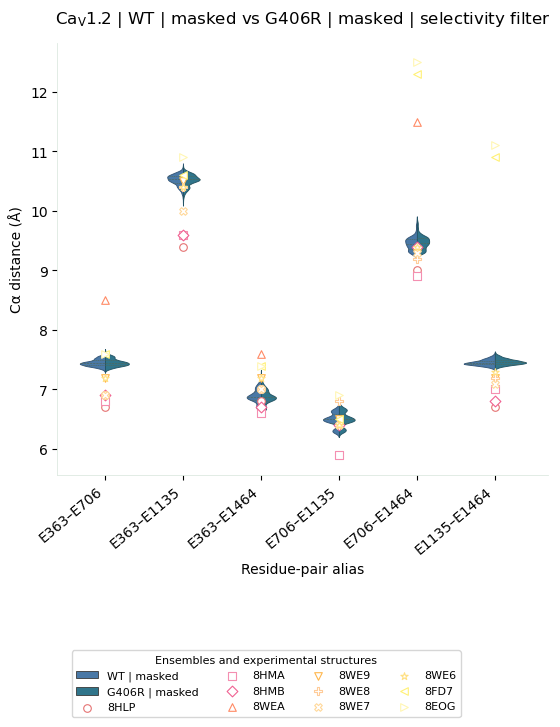

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


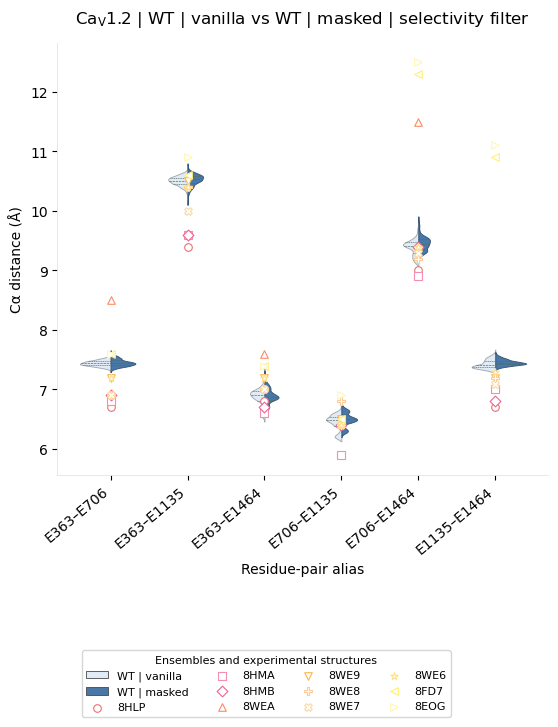

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


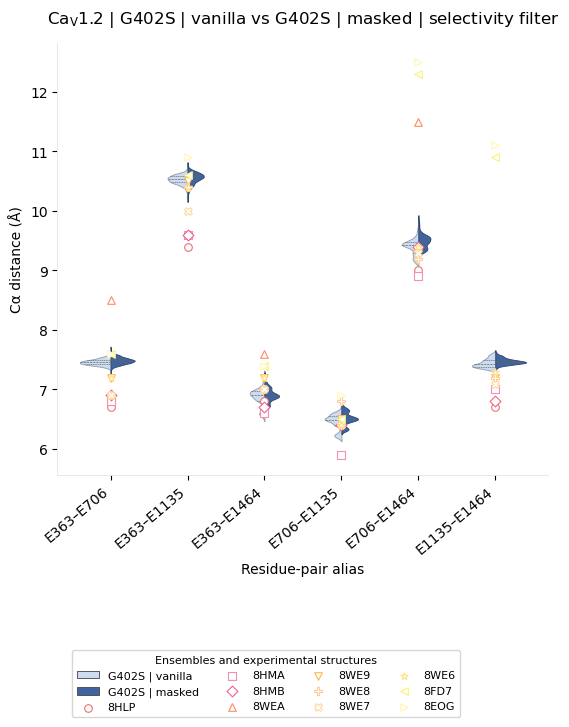

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


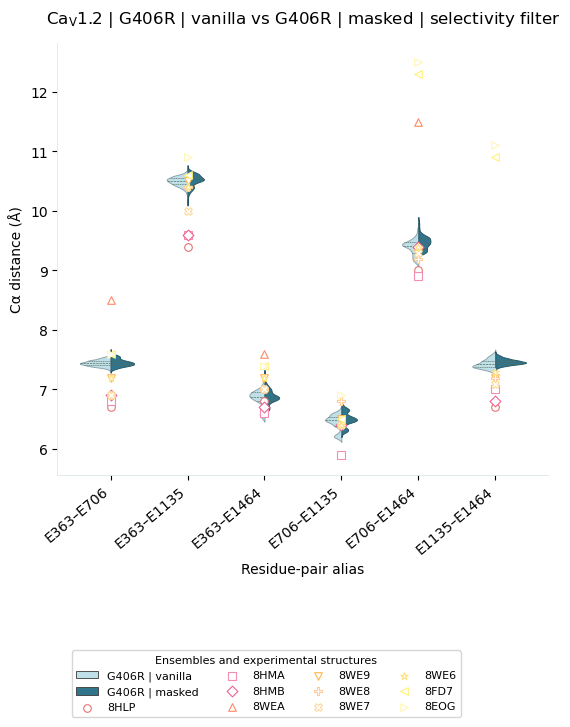

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


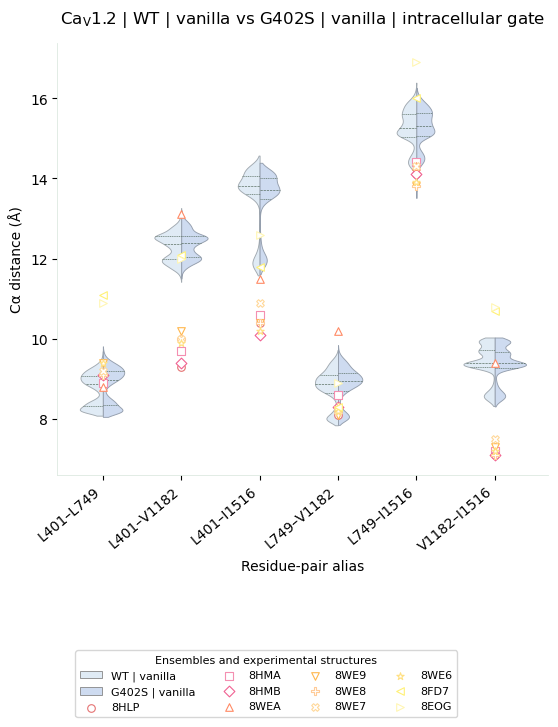

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


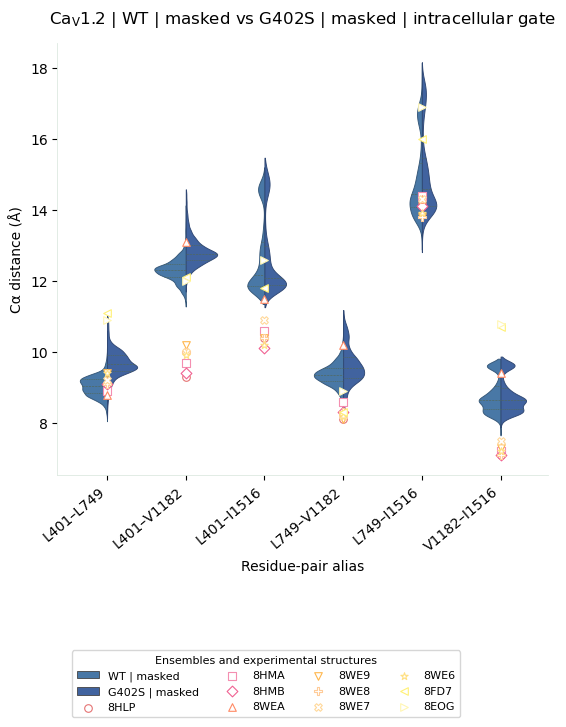

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


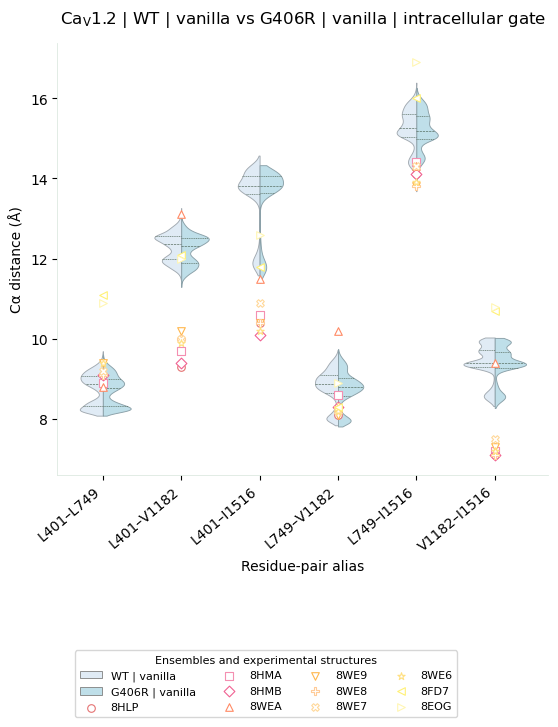

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


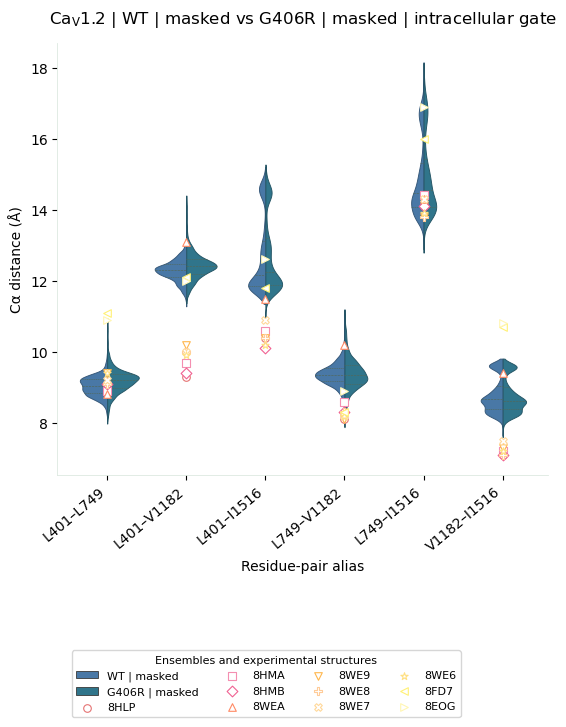

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


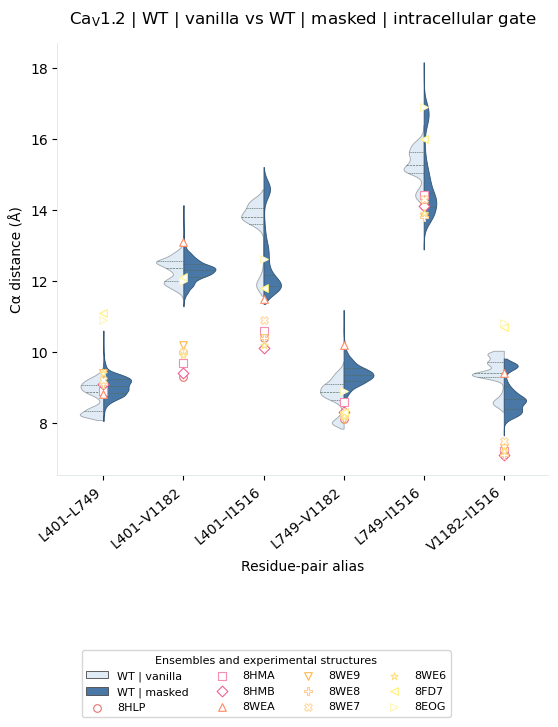

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


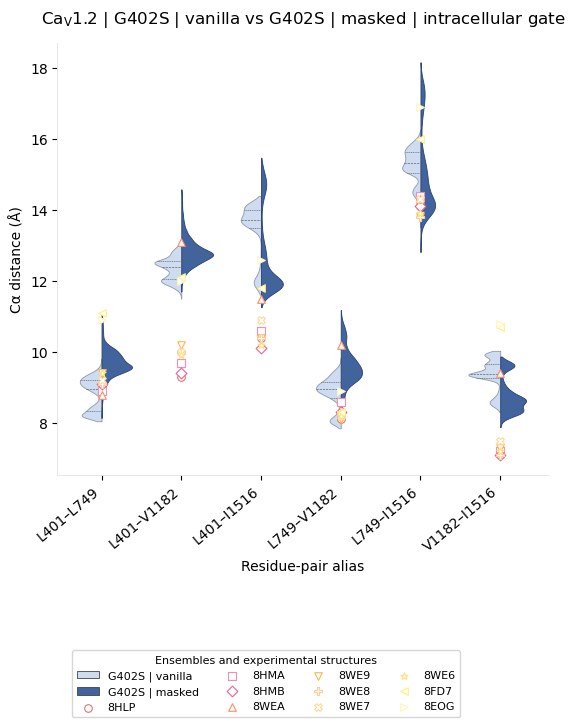

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


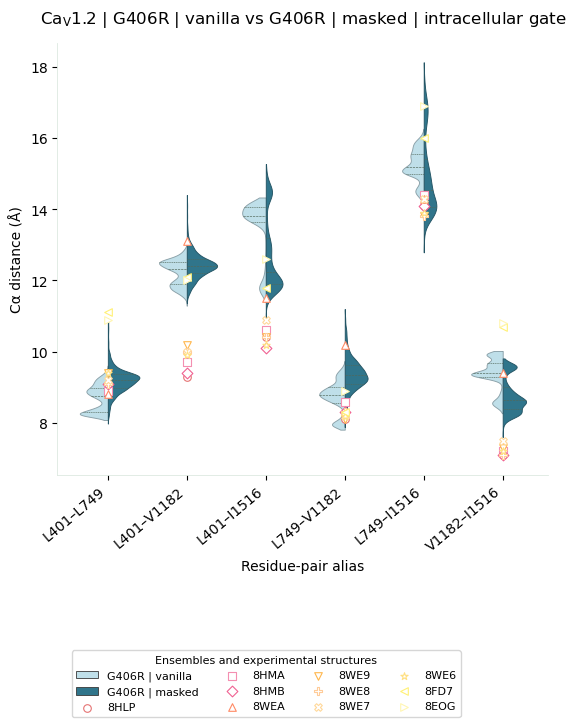

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


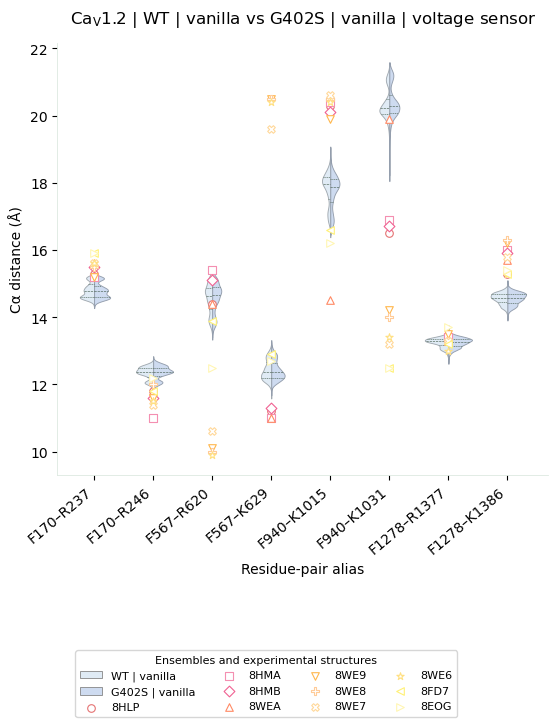

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


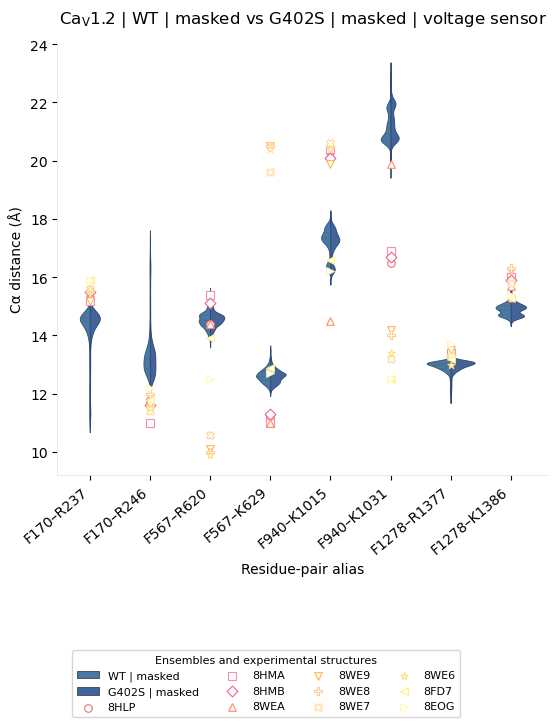

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


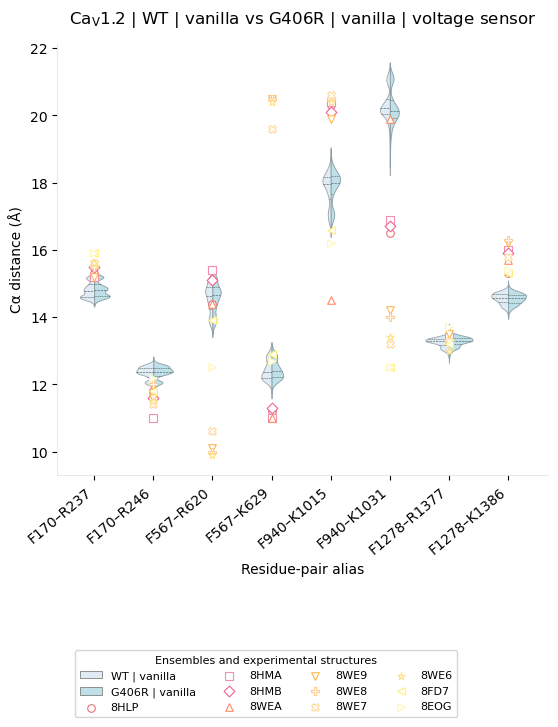

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


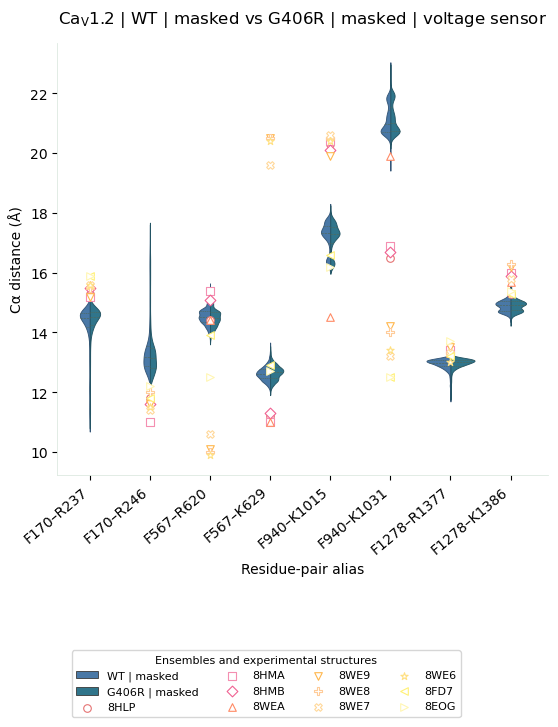

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


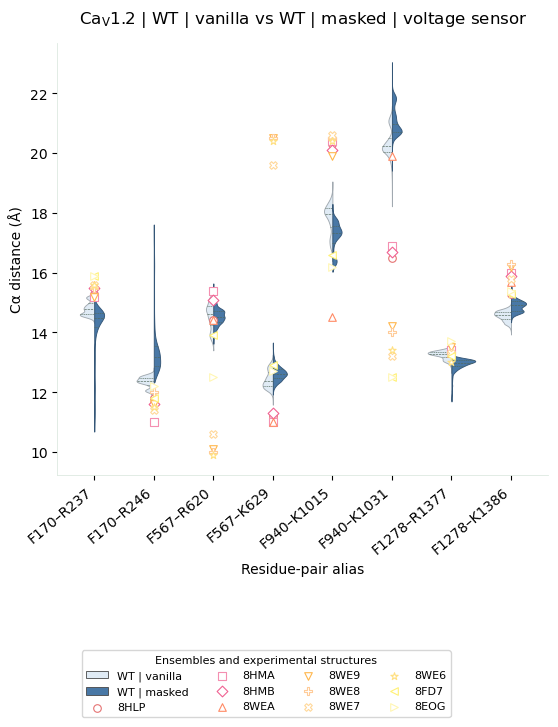

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


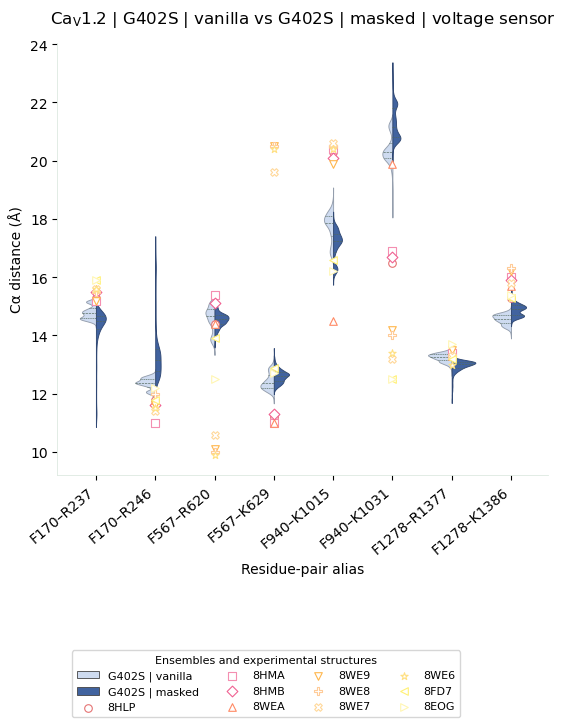

/Users/ahernandezgonzalez/Repositories/vgci_mutants/shared/plotting.py:281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


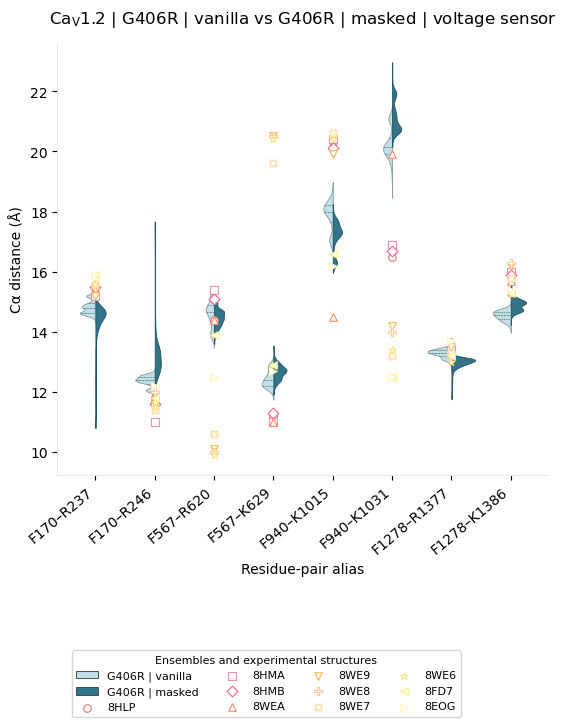

,Ensemble,Protocol,n,Gate median (Å),Gate IQR (Å),Gate SD (Å),State median (Å),State IQR (Å),Spearman gate–state,Gate IQR / WT,Gate–state coordination,Sampling interpretation
0,WT,vanilla,5000,15.26,0.580,0.485,17.36,0.87,-0.497,1.000,moderate negative,WT reference
1,G402S,vanilla,5000,15.32,0.580,0.458,17.60,0.87,-0.365,1.000,moderate negative,similar gate sampling; coordinated
2,WT,masked,4996,14.46,1.240,1.043,18.04,0.71,-0.526,1.000,strong negative,WT reference
3,G402S,masked,4995,14.58,1.345,1.174,18.39,0.79,-0.517,1.085,strong negative,similar gate sampling; coordinated
4,WT,vanilla,5000,15.26,0.580,0.485,8.92,1.03,0.022,1.000,weak positive,WT reference
5,G406R,vanilla,5000,15.19,0.580,0.450,10.28,0.42,0.278,1.000,weak positive,similar gate sampling; not clearly coordinated
6,WT,masked,4996,14.46,1.240,1.043,9.73,0.61,-0.522,1.000,strong negative,WT reference
7,G406R,masked,4997,14.54,1.350,1.087,10.68,0.41,-0.437,1.089,moderate negative,similar gate sampling; coordinated


,Protocol,VSD landmark,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT IQR (Å),Mutant IQR (Å),Mutant / WT IQR
0,vanilla,F170-R237,14.78,14.77,-0.01,0.370,0.34,0.919
1,vanilla,F170-R246,12.37,12.38,0.01,0.260,0.26,1.000
2,vanilla,F567-R620,14.63,14.66,0.03,0.640,0.60,0.937
3,vanilla,F567-K629,12.38,12.36,-0.02,0.480,0.43,0.896
4,vanilla,F940-K1015,17.95,17.87,-0.08,0.640,0.68,1.062
5,vanilla,F940-K1031,20.22,20.30,0.08,0.450,0.53,1.178
6,vanilla,F1278-R1377,13.28,13.27,-0.01,0.200,0.21,1.050
7,vanilla,F1278-K1386,14.58,14.58,0.00,0.250,0.27,1.080
8,masked,F170-R237,14.49,14.50,0.01,0.470,0.46,0.979
9,masked,F170-R246,13.19,13.15,-0.04,0.650,0.75,1.154


,Protocol,VSD landmark,WT median (Å),Mutant median (Å),Mutant − WT (Å),WT IQR (Å),Mutant IQR (Å),Mutant / WT IQR
0,vanilla,F170-R237,14.78,14.80,0.02,0.370,0.340,0.919
1,vanilla,F170-R246,12.37,12.38,0.01,0.260,0.240,0.923
2,vanilla,F567-R620,14.63,14.65,0.02,0.640,0.620,0.969
3,vanilla,F567-K629,12.38,12.39,0.01,0.480,0.440,0.917
4,vanilla,F940-K1015,17.95,18.00,0.05,0.640,0.562,0.879
5,vanilla,F940-K1031,20.22,20.14,-0.08,0.450,0.530,1.178
6,vanilla,F1278-R1377,13.28,13.30,0.02,0.200,0.200,1.000
7,vanilla,F1278-K1386,14.58,14.56,-0.02,0.250,0.240,0.960
8,masked,F170-R237,14.49,14.53,0.04,0.470,0.450,0.957
9,masked,F170-R246,13.19,13.13,-0.06,0.650,0.650,1.000


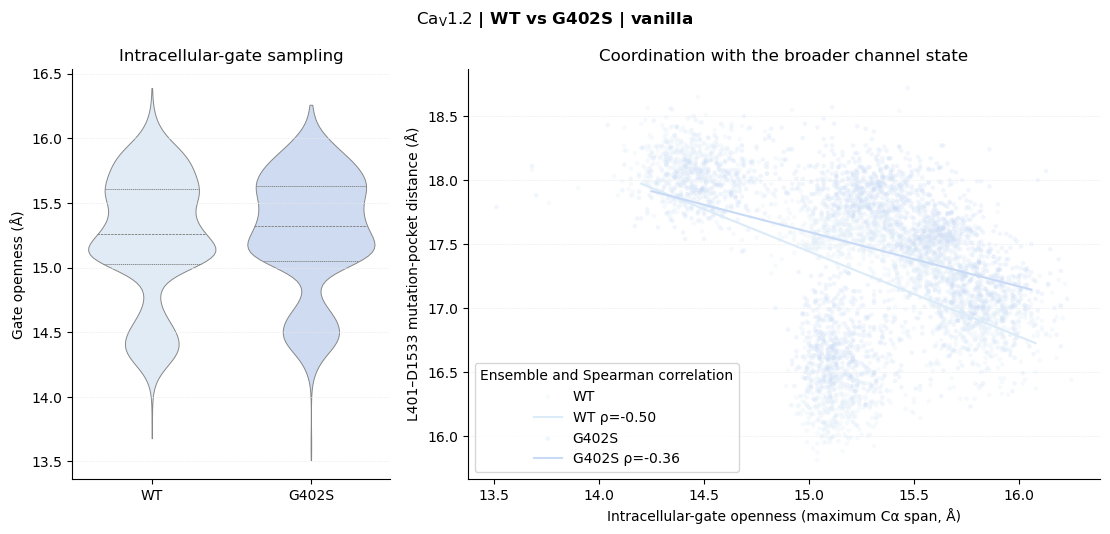

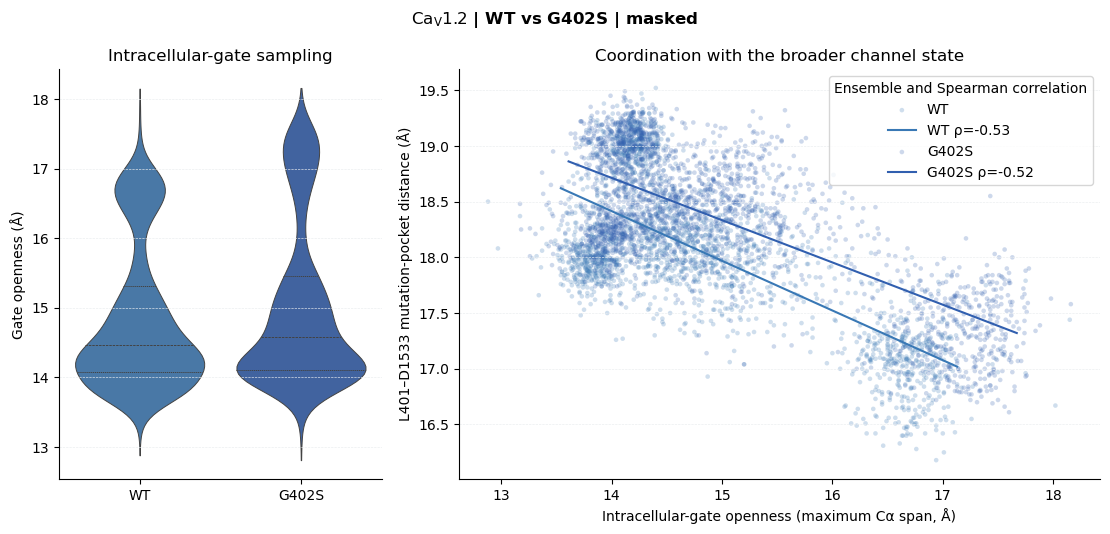

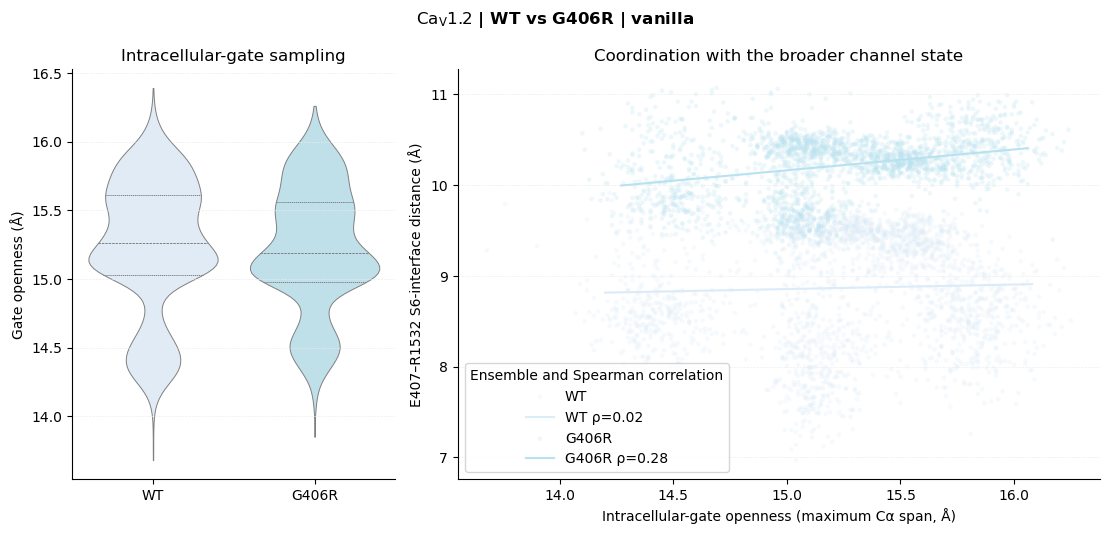

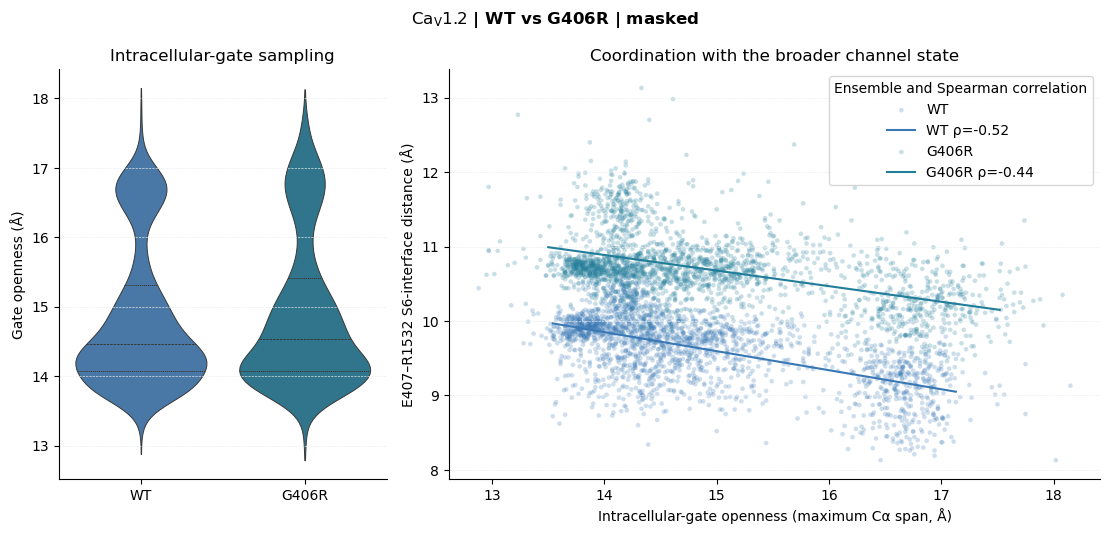

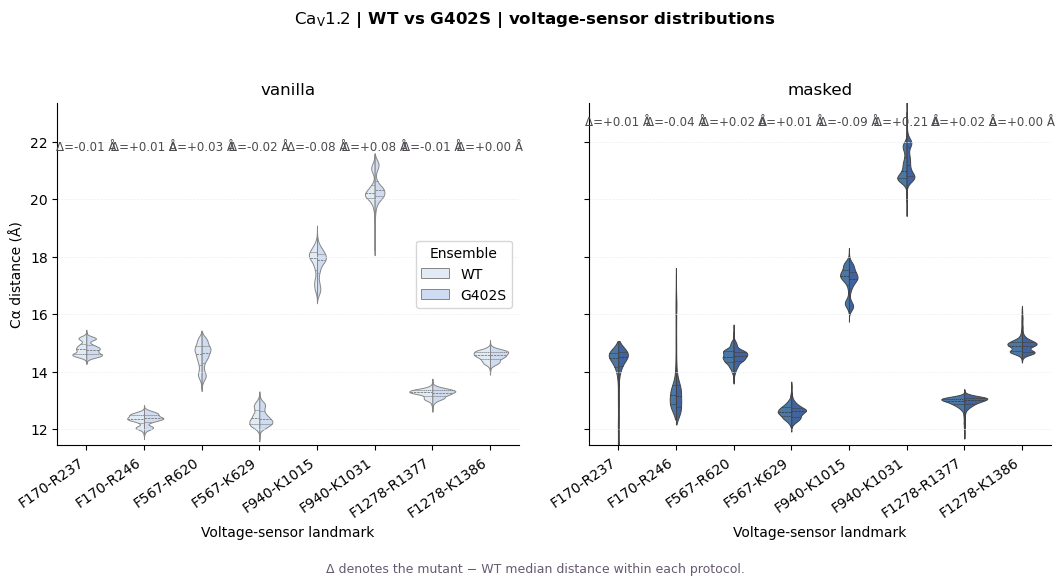

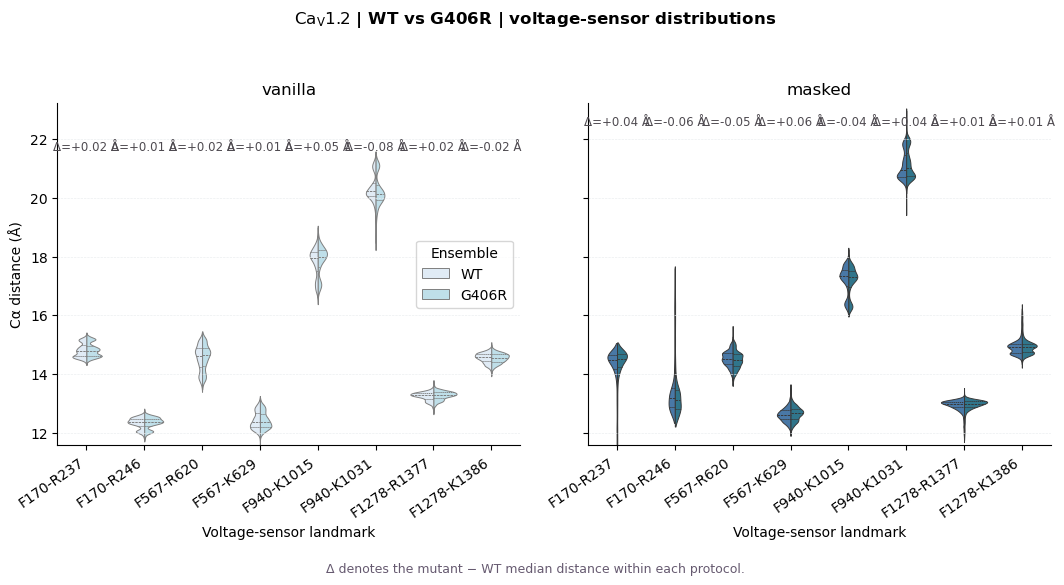

In [12]:
from shared.plotting import plot_pairwise_split_violin as cav_split

## Split-violin alternatives
import seaborn as sns, matplotlib.pyplot as plt


# The experimental-overlay panels above are used for interpretation.

## Split violins with experimental structures
from shared.plotting import plot_split_comparison_with_experimentals
from shared.experimental_overlays import experimental_rows

CAV12_SPLIT_COMPARISONS = [
    ('WT | vanilla', df_wt_vanilla, 'G402S | vanilla', df_g402s_vanilla, CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G402S_VAN']),
    ('WT | masked', df_wt_masked, 'G402S | masked', df_g402s_masked, CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G402S_HM']),
    ('WT | vanilla', df_wt_vanilla, 'G406R | vanilla', df_g406r_vanilla, CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G406R_VAN']),
    ('WT | masked', df_wt_masked, 'G406R | masked', df_g406r_masked, CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G406R_HM']),
    ('WT | vanilla', df_wt_vanilla, 'WT | masked', df_wt_masked, CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['WT_HM']),
    ('G402S | vanilla', df_g402s_vanilla, 'G402S | masked', df_g402s_masked, CAV12_PALETTE['G402S_VAN'], CAV12_PALETTE['G402S_HM']),
    ('G406R | vanilla', df_g406r_vanilla, 'G406R | masked', df_g406r_masked, CAV12_PALETTE['G406R_VAN'], CAV12_PALETTE['G406R_HM']),
]
for region_key, aliases in CAV12_MUTATION_CORRESPONDENCE.items():
    references = experimental_rows(repo_root, 'Cav1.2', region_key, aliases)
    region_label = region_key.replace('_', ' ')
    for label1, frame1, label2, frame2, color1, color2 in CAV12_SPLIT_COMPARISONS:
        plot_split_comparison_with_experimentals(
            frame1, frame2, aliases, label1, label2,
            f'Cav1.2 | {label1} vs {label2} | {region_label} | experimental distances',
            [color1, color2], references,
        )

## Gate openness and coordinated channel-state sampling
# A wider gate distribution is only interpreted as broader state sampling when it
# varies coherently with a second, mutation-relevant coordinate.
from shared.channel_state_analysis import plot_gate_state_comparison
CAV12_GATE_ALIASES = CAV12_MUTATION_CORRESPONDENCE['intracellular_gate']
cav_state_tests = [
    ('G402S', 'vanilla', df_wt_vanilla, df_g402s_vanilla, ['CA_LEU401_CA-ASP1533_CA'], 'L401–D1533 mutation-pocket distance (Å)', [CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G402S_VAN']]),
    ('G402S', 'masked', df_wt_masked, df_g402s_masked, ['CA_LEU401_CA-ASP1533_CA'], 'L401–D1533 mutation-pocket distance (Å)', [CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G402S_HM']]),
    ('G406R', 'vanilla', df_wt_vanilla, df_g406r_vanilla, ['CA_GLU407_CA-ARG1532_CA'], 'E407–R1532 S6-interface distance (Å)', [CAV12_PALETTE['WT_VAN'], CAV12_PALETTE['G406R_VAN']]),
    ('G406R', 'masked', df_wt_masked, df_g406r_masked, ['CA_GLU407_CA-ARG1532_CA'], 'E407–R1532 S6-interface distance (Å)', [CAV12_PALETTE['WT_HM'], CAV12_PALETTE['G406R_HM']]),
]
cav_gate_state_summary = []
for mutant, protocol, wt_frame, mutant_frame, state_columns, state_label, colors in cav_state_tests:
    summary, _ = plot_gate_state_comparison(wt_frame, mutant_frame, CAV12_GATE_ALIASES, state_columns, state_columns, 'Cav1.2', mutant, protocol, state_label, colors)
    cav_gate_state_summary.append(summary)
cav_gate_state_summary = pd.concat(cav_gate_state_summary, ignore_index=True)
display(cav_gate_state_summary.round(3))

## WT-versus-mutant voltage-sensor bias in both protocols
from shared.channel_state_analysis import plot_vsd_bias
CAV12_VSD_ALIASES = CAV12_MUTATION_CORRESPONDENCE['voltage_sensor']
for mutant, vanilla_frame, masked_frame, colors in [
    ('G402S', df_g402s_vanilla, df_g402s_masked, {'vanilla': CAV12_PALETTE['G402S_VAN'], 'masked': CAV12_PALETTE['G402S_HM']}),
    ('G406R', df_g406r_vanilla, df_g406r_masked, {'vanilla': CAV12_PALETTE['G406R_VAN'], 'masked': CAV12_PALETTE['G406R_HM']}),
]:
    bias_table, _ = plot_vsd_bias(
        {'vanilla': (df_wt_vanilla, vanilla_frame), 'masked': (df_wt_masked, masked_frame)},
        CAV12_VSD_ALIASES, 'Cav1.2', mutant, colors,
    )
    display(bias_table.round(3))
